# Block delivery from relays - EDA

#### Maria Silva, July 2025


## 1. Imports

In [1]:
import os
import json
import pytz
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from sqlalchemy import text, create_engine

In [2]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))

In [3]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

In [4]:
def convert_slot_number_to_date_string(slot: int) -> str:
    slot_timestamp = slot * 12 + 1606824023
    slot_date = datetime.fromtimestamp(slot_timestamp, tz=pytz.timezone("UTC"))
    slot_date_str = slot_date.strftime("%Y-%m-%d %H:%M:%S")
    return slot_date_str

In [5]:
# Secrets for acessing xatu clickhouse and erigon
with open(os.path.join(repo_dir, "secrets.json"), "r") as file:
    secrets_dict = json.load(file)

# Credentials for xatu clickhouse
xatu_user = secrets_dict["xatu_username"]
xatu_pass = secrets_dict["xatu_password"]

db_url = db_url = (
        f"clickhouse+http://{xatu_user}:{xatu_pass}@"
        "clickhouse.xatu.ethpandaops.io:443/default?protocol=https"
    )

## 2. Data processing

### Ultrasound relay data

In [6]:
# Load raw data from ultrasound
ultra_file = os.path.join(
    repo_dir, "data", "relay", "ultrasoud_payload_publish_time_07_21_17_32.csv"
)
ultra_df = pd.read_csv(ultra_file)
ultra_df["request_datetime"] = pd.to_datetime(ultra_df["received_at"]).dt.tz_localize(
    None
)
ultra_df["publish_datetime"] = pd.to_datetime(
    ultra_df["time_before_publish"]
).dt.tz_localize(None)
ultra_df = ultra_df[ultra_df["is_ultra_sound_header"]]
ultra_df = ultra_df[["slot", "request_datetime", "publish_datetime"]]
ultra_df["source"] = "ultrasound"
ultra_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91781 entries, 0 to 100257
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   slot              91781 non-null  int64         
 1   request_datetime  91781 non-null  datetime64[ns]
 2   publish_datetime  91781 non-null  datetime64[ns]
 3   source            91781 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 3.5+ MB


In [7]:
ultra_df["slot"].agg(["min", "max"])

min    11974663
max    12190656
Name: slot, dtype: int64

### Titan relay data

In [8]:
# Load raw data from titan
titan_file = os.path.join(repo_dir, "data", "relay", "block_times_since_12187616.csv")
titan_df = pd.read_csv(titan_file)
titan_df = titan_df.rename(columns={"slot_number": "slot"})
titan_df["request_datetime"] = pd.to_datetime(titan_df["header_request_received"])
titan_df["publish_datetime"] = pd.to_datetime(titan_df["block_published"])
titan_df = titan_df[["slot", "request_datetime", "publish_datetime"]]
titan_df["source"] = "titan"
titan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   slot              490 non-null    int64         
 1   request_datetime  490 non-null    datetime64[ns]
 2   publish_datetime  490 non-null    datetime64[ns]
 3   source            490 non-null    object        
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 15.4+ KB


In [9]:
titan_df["slot"].agg(["min", "max"])

min    12187630
max    12204166
Name: slot, dtype: int64

### Slot times

In [10]:
# Define dates for queries
slot_start = 11974663
slot_end = 12204166
start_date_str = convert_slot_number_to_date_string(slot_start-2)
end_date_str = convert_slot_number_to_date_string(slot_end+2)
# Define and run query
query_str = f"""
    SELECT DISTINCT slot, slot_start_date_time AS slot_start_datetime
    FROM default.canonical_beacon_block FINAL
    WHERE slot_start_date_time BETWEEN toDateTime('{start_date_str}') AND toDateTime('{end_date_str}')
        AND meta_network_name = 'mainnet'
"""
engine = create_engine(db_url)
slot_start_df = pd.read_sql(query_str, con=engine)
slot_start_df["slot_start_datetime"] = pd.to_datetime(
    slot_start_df["slot_start_datetime"]
)
slot_start_df

,slot,slot_start_datetime
0,12041994,2025-06-30 23:59:11
1,12041995,2025-06-30 23:59:23
2,12042003,2025-07-01 00:00:59
3,12042006,2025-07-01 00:01:35
4,12042007,2025-07-01 00:01:47
...,...,...
228144,12195896,2025-07-22 08:59:35
228145,12195897,2025-07-22 08:59:47
228146,12195900,2025-07-22 09:00:23
228147,12195902,2025-07-22 09:00:47


### Join relay data

In [41]:
# Join data
relay_df = (
    pd.concat([ultra_df, titan_df], ignore_index=True)
    .merge(slot_start_df, on="slot", how="inner")
    .sort_values(by="request_datetime")
)
# Compute times
relay_df["request_to_publish"] = (
    relay_df["publish_datetime"] - relay_df["request_datetime"]
).dt.total_seconds()*1000
relay_df["slot_start_to_request"] = (
    relay_df["request_datetime"] - relay_df["slot_start_datetime"]
).dt.total_seconds()*1000
relay_df["slot_start_to_publish"] = (
    relay_df["publish_datetime"] - relay_df["slot_start_datetime"]
).dt.total_seconds()*1000
# Filter data bugs
relay_df = relay_df[relay_df["slot_start_to_publish"].between(0,4000)]
relay_df = relay_df[relay_df["slot_start_to_request"]>0]
relay_df = relay_df[relay_df["request_to_publish"]>0]
# Get first request by slot
relay_df = relay_df.groupby("slot").first().reset_index().sort_values(by="slot")

relay_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91931 entries, 0 to 91930
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   slot                   91931 non-null  int64         
 1   request_datetime       91931 non-null  datetime64[ns]
 2   publish_datetime       91931 non-null  datetime64[ns]
 3   source                 91931 non-null  object        
 4   slot_start_datetime    91931 non-null  datetime64[ns]
 5   request_to_publish     91931 non-null  float64       
 6   slot_start_to_request  91931 non-null  float64       
 7   slot_start_to_publish  91931 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(1), object(1)
memory usage: 5.6+ MB


In [42]:
relay_df["slot"].nunique()

91931

In [43]:
relay_df.groupby("source").size()

source
titan           184
ultrasound    91747
dtype: int64

## 3. Time to request distribution

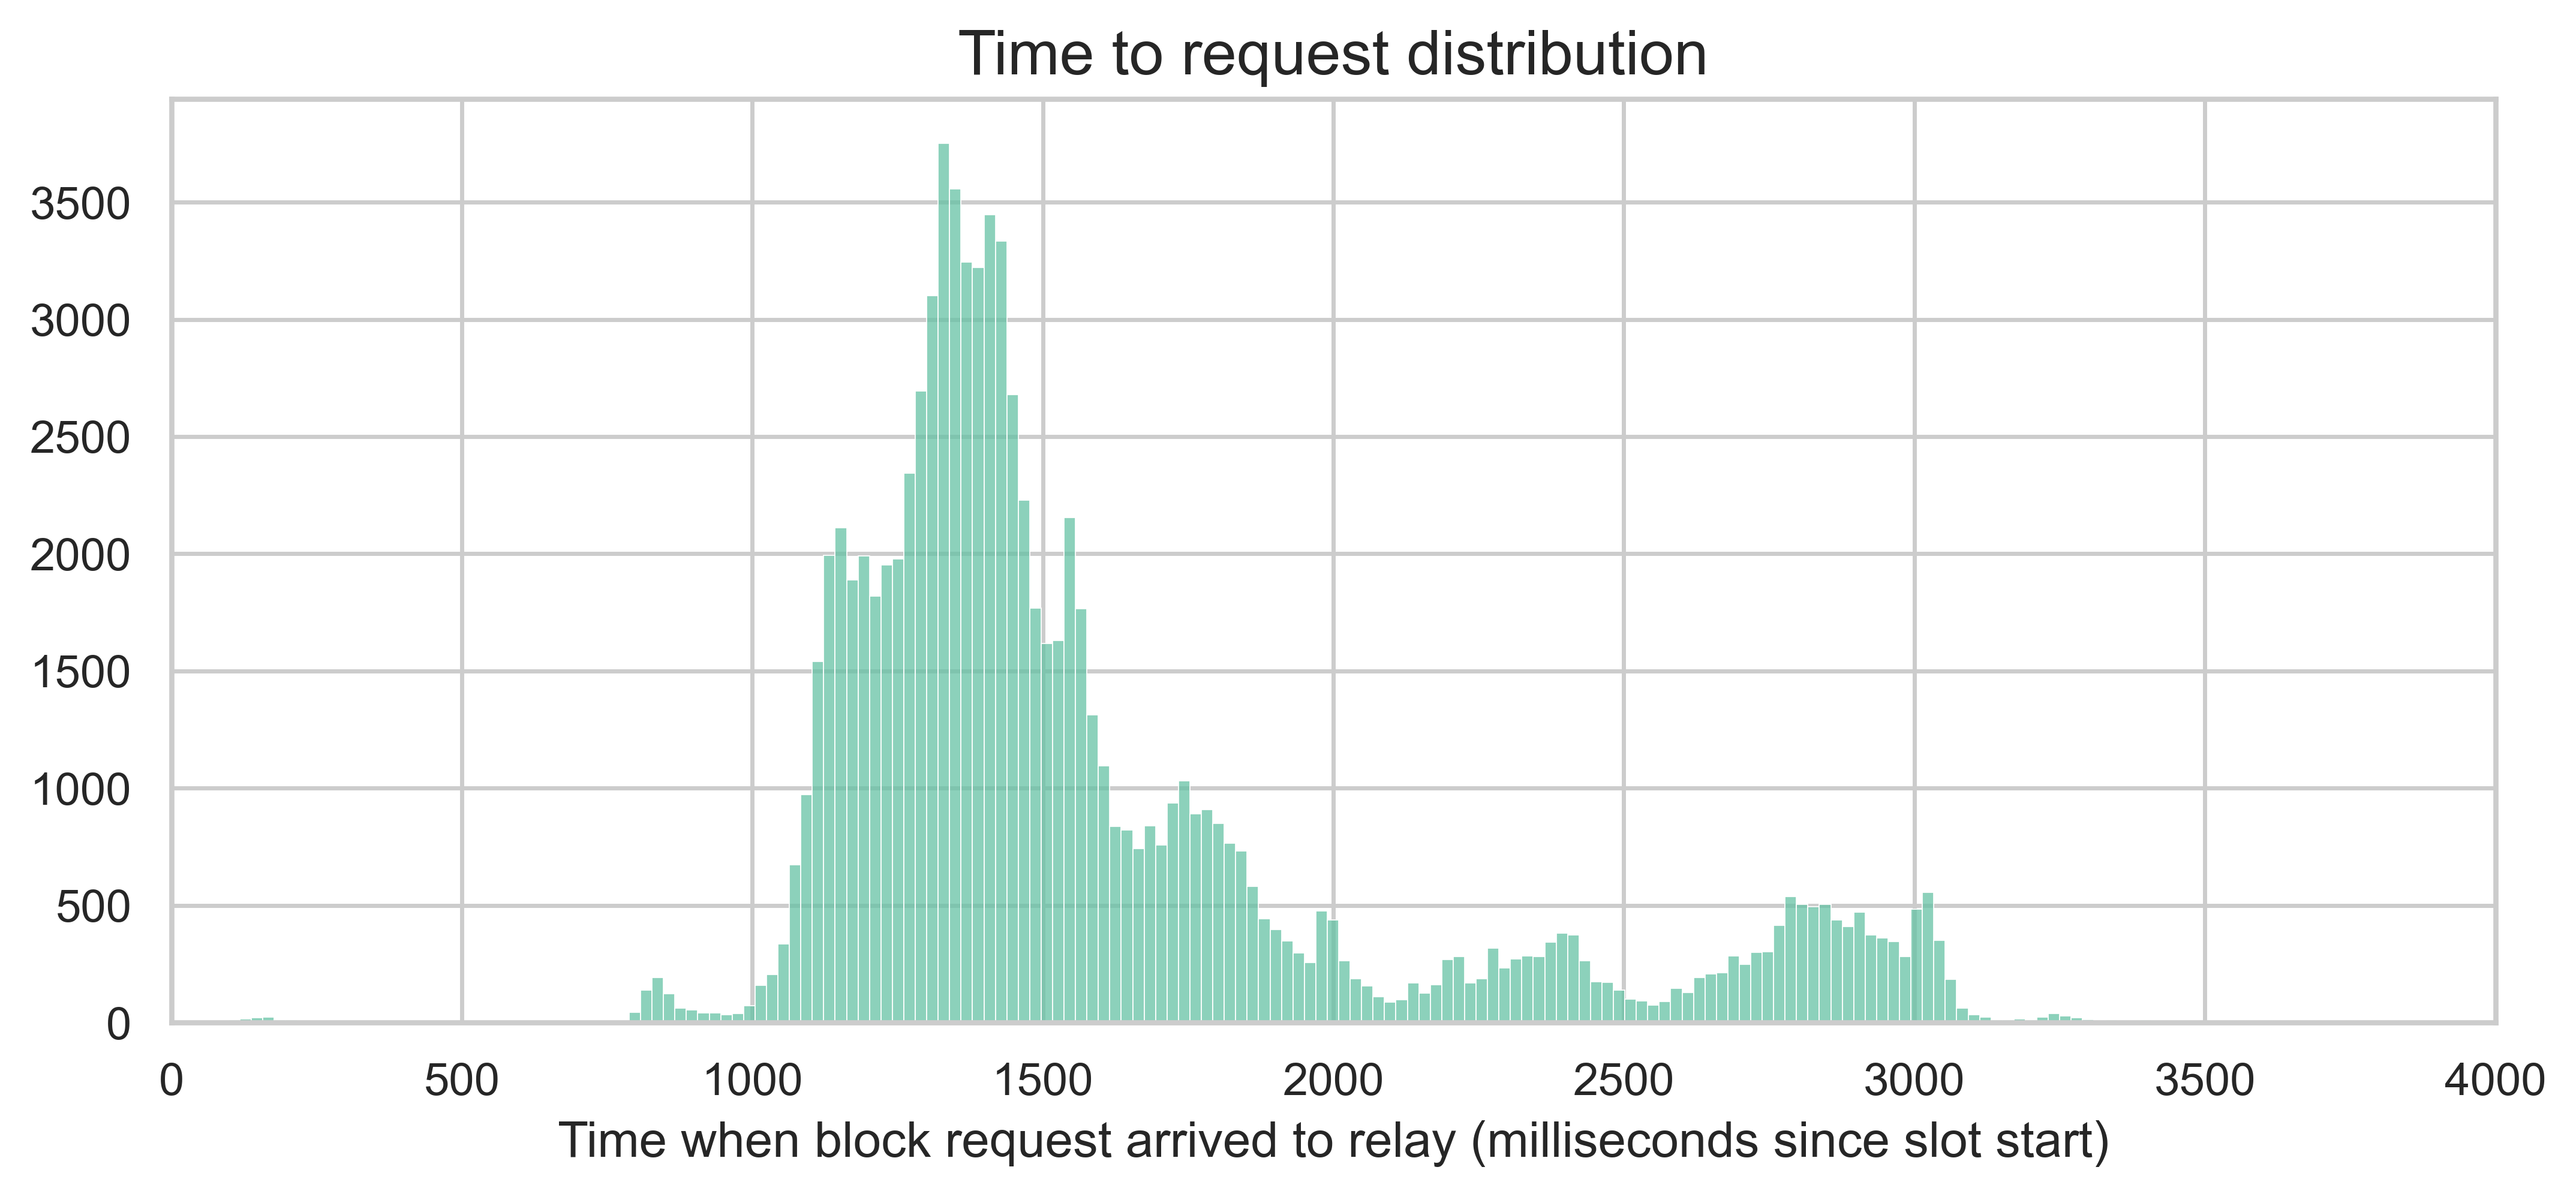

In [46]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=relay_df,
    x="slot_start_to_request",
)
plt.xlim(0,4000)
plt.title("Time to request distribution")
plt.ylabel("")
plt.xlabel("Time when block request arrived to relay (milliseconds since slot start)")
plt.show()

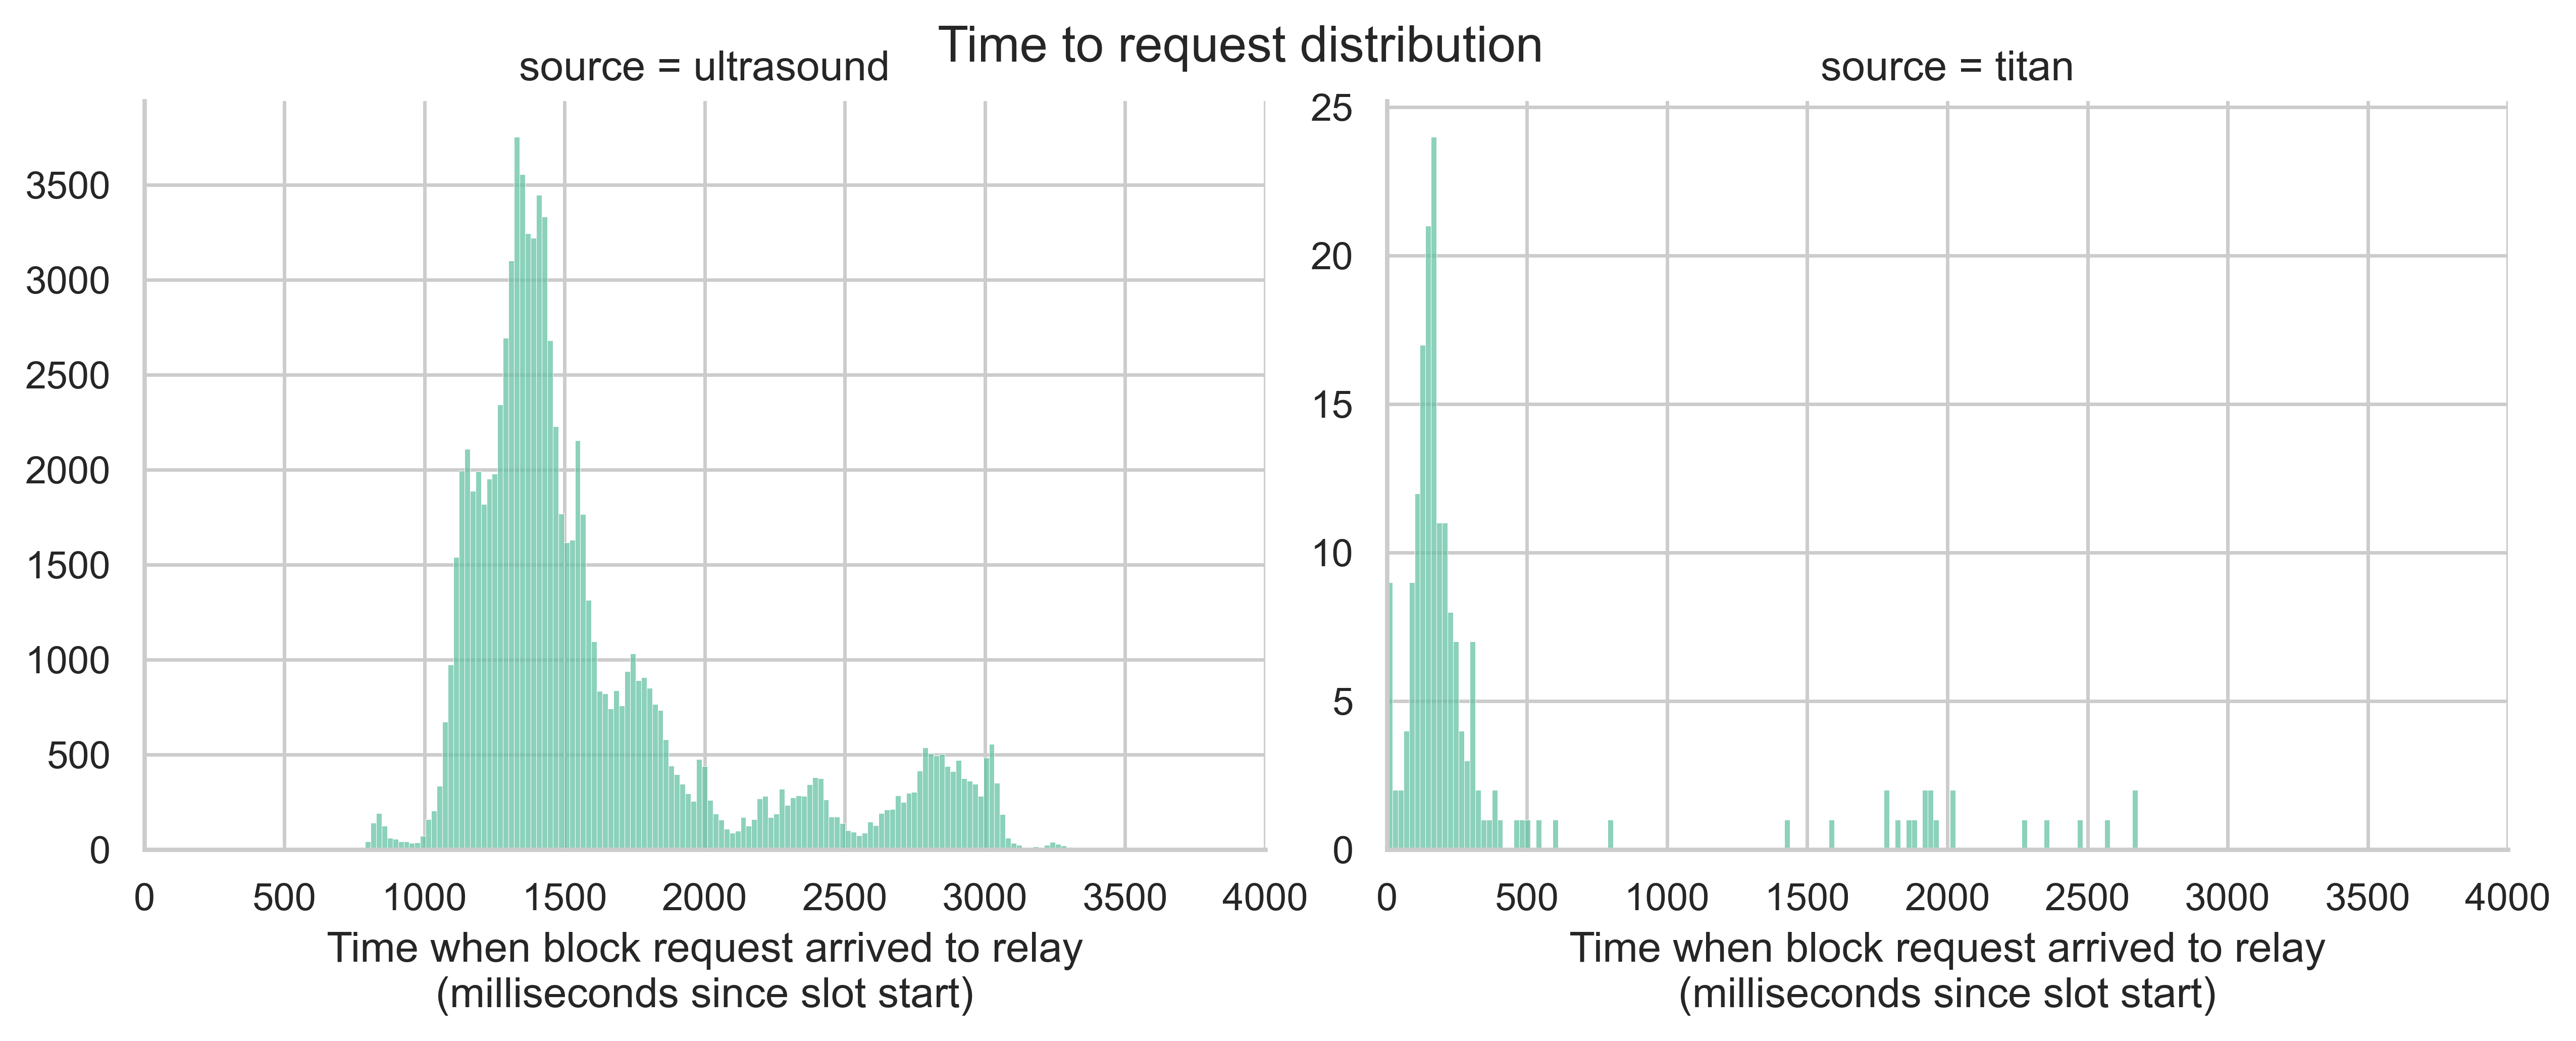

In [47]:

g = sns.displot(
    data=relay_df,
    x="slot_start_to_request",
    col="source",
    kind="hist",
    height=4, aspect=1.3,
    facet_kws={"sharey":False}
)
g.set(xlim=(0,4000))
g.set_xlabels("Time when block request arrived to relay\n(milliseconds since slot start)")
g.set_ylabels("")
plt.suptitle("Time to request distribution")
plt.show()

In [52]:
relay_df["slot_start_to_request"].agg(["min", "max", "mean", "std"])

min        0.078458
max     3979.000000
mean    1612.732484
std      516.239775
Name: slot_start_to_request, dtype: float64

In [53]:
relay_df["slot_start_to_request"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    1296.0
0.50    1430.0
0.75    1742.0
0.90    2565.0
0.95    2858.0
0.99    3033.0
Name: slot_start_to_request, dtype: float64

## 4. Time to publish distribution

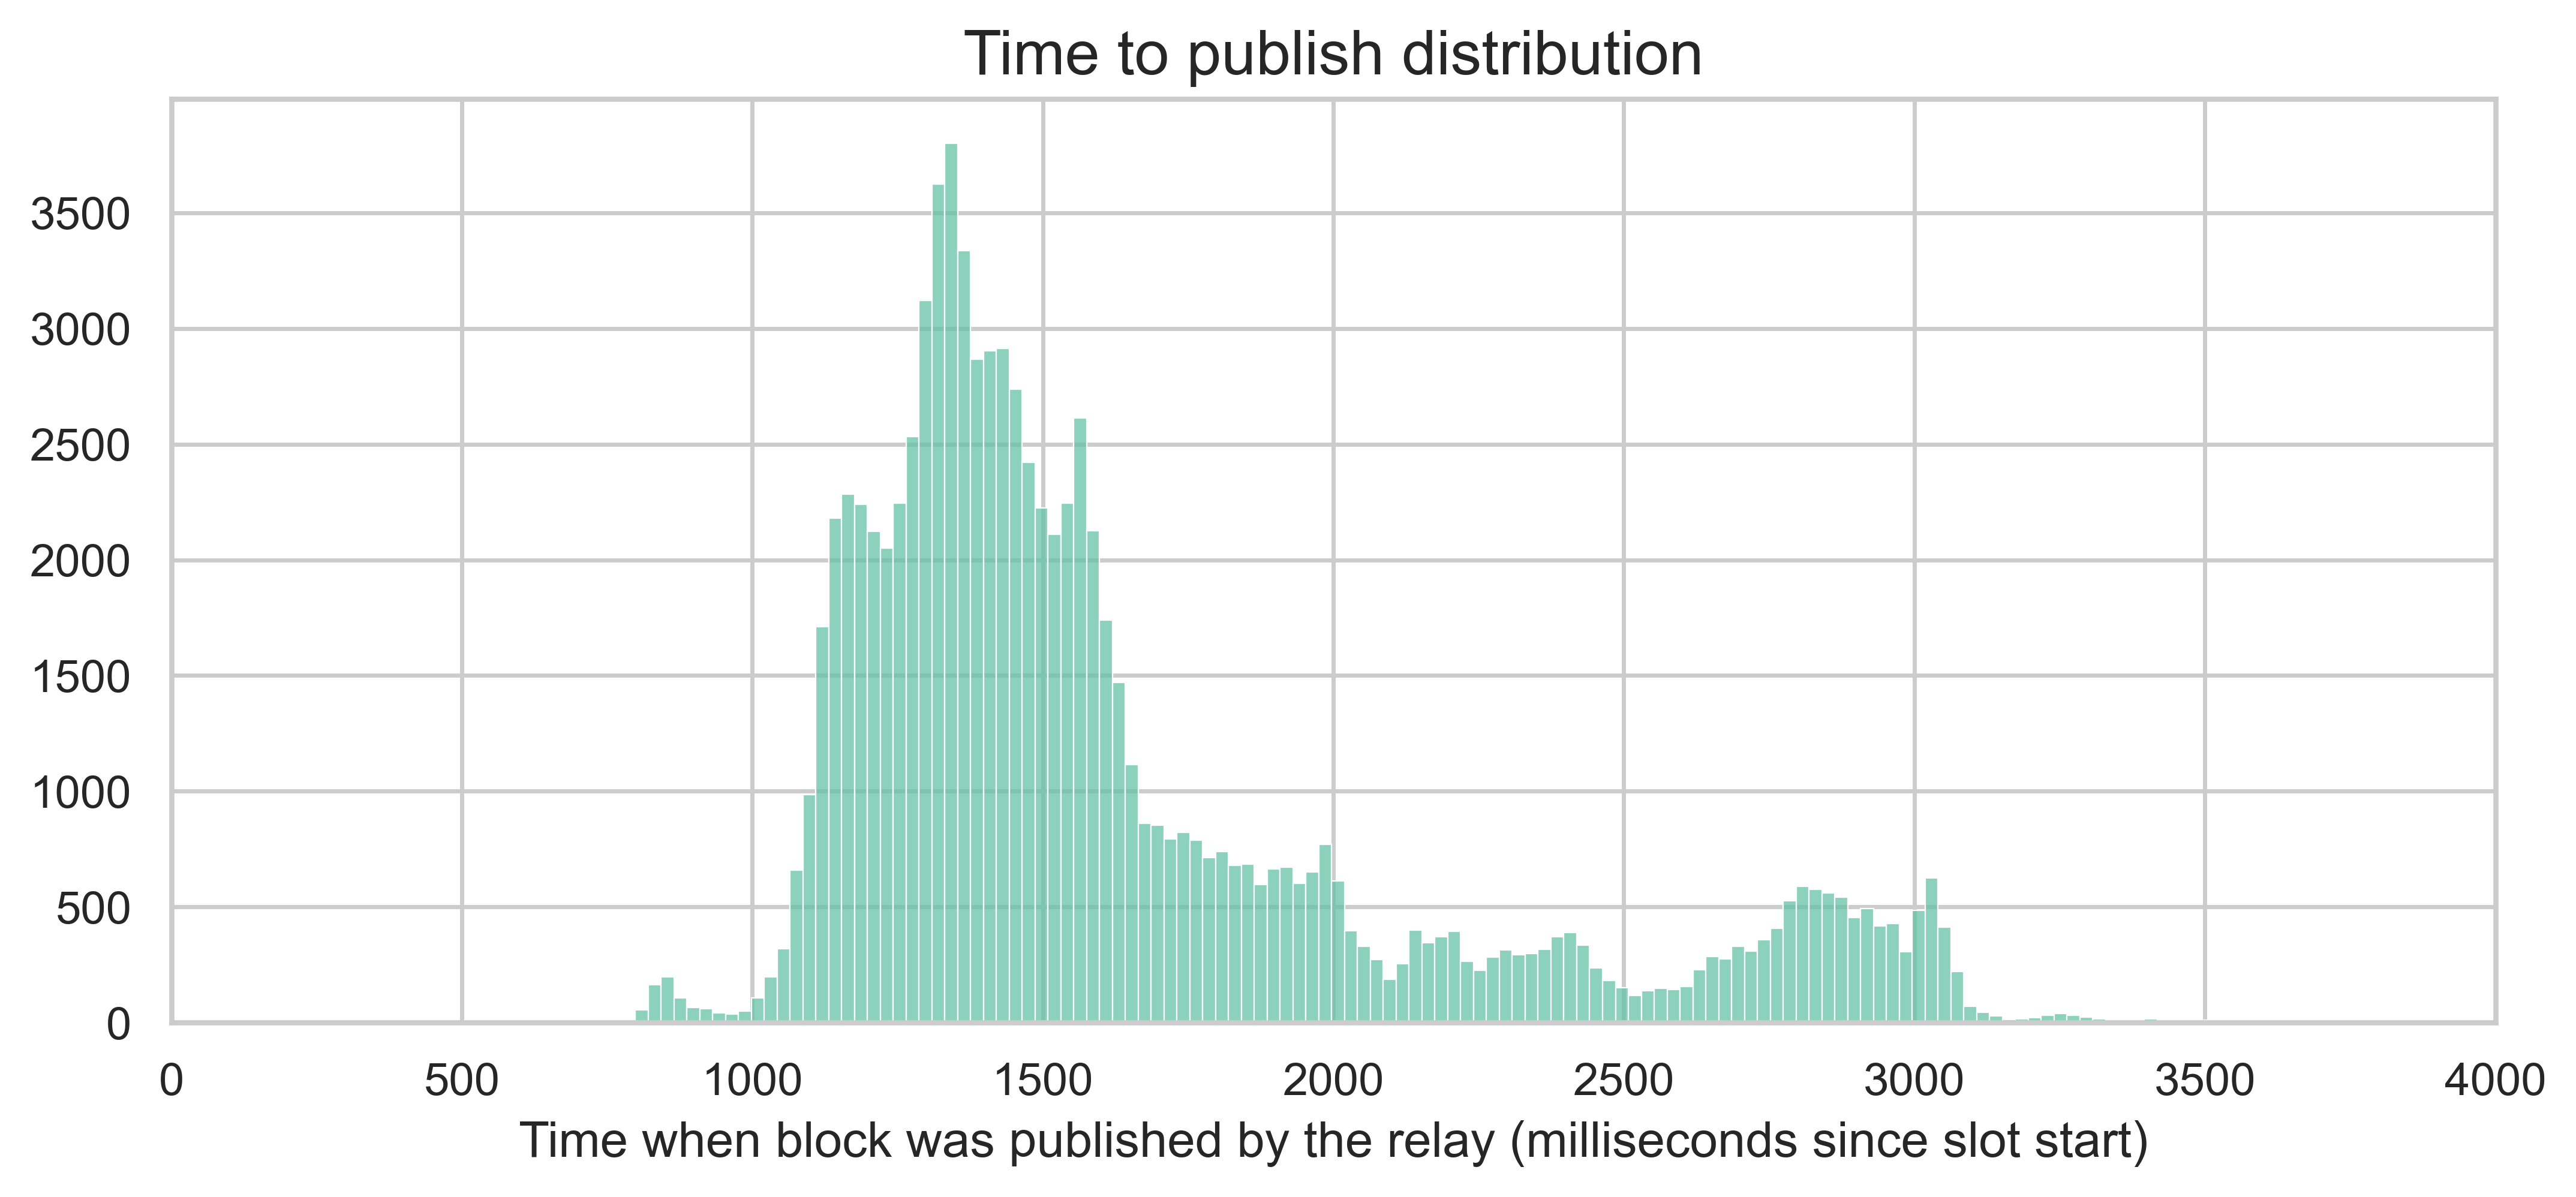

In [51]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=relay_df,
    x="slot_start_to_publish",
)
plt.xlim(0,4000)
plt.title("Time to publish distribution")
plt.ylabel("")
plt.xlabel("Time when block was published by the relay (milliseconds since slot start)")
plt.show()

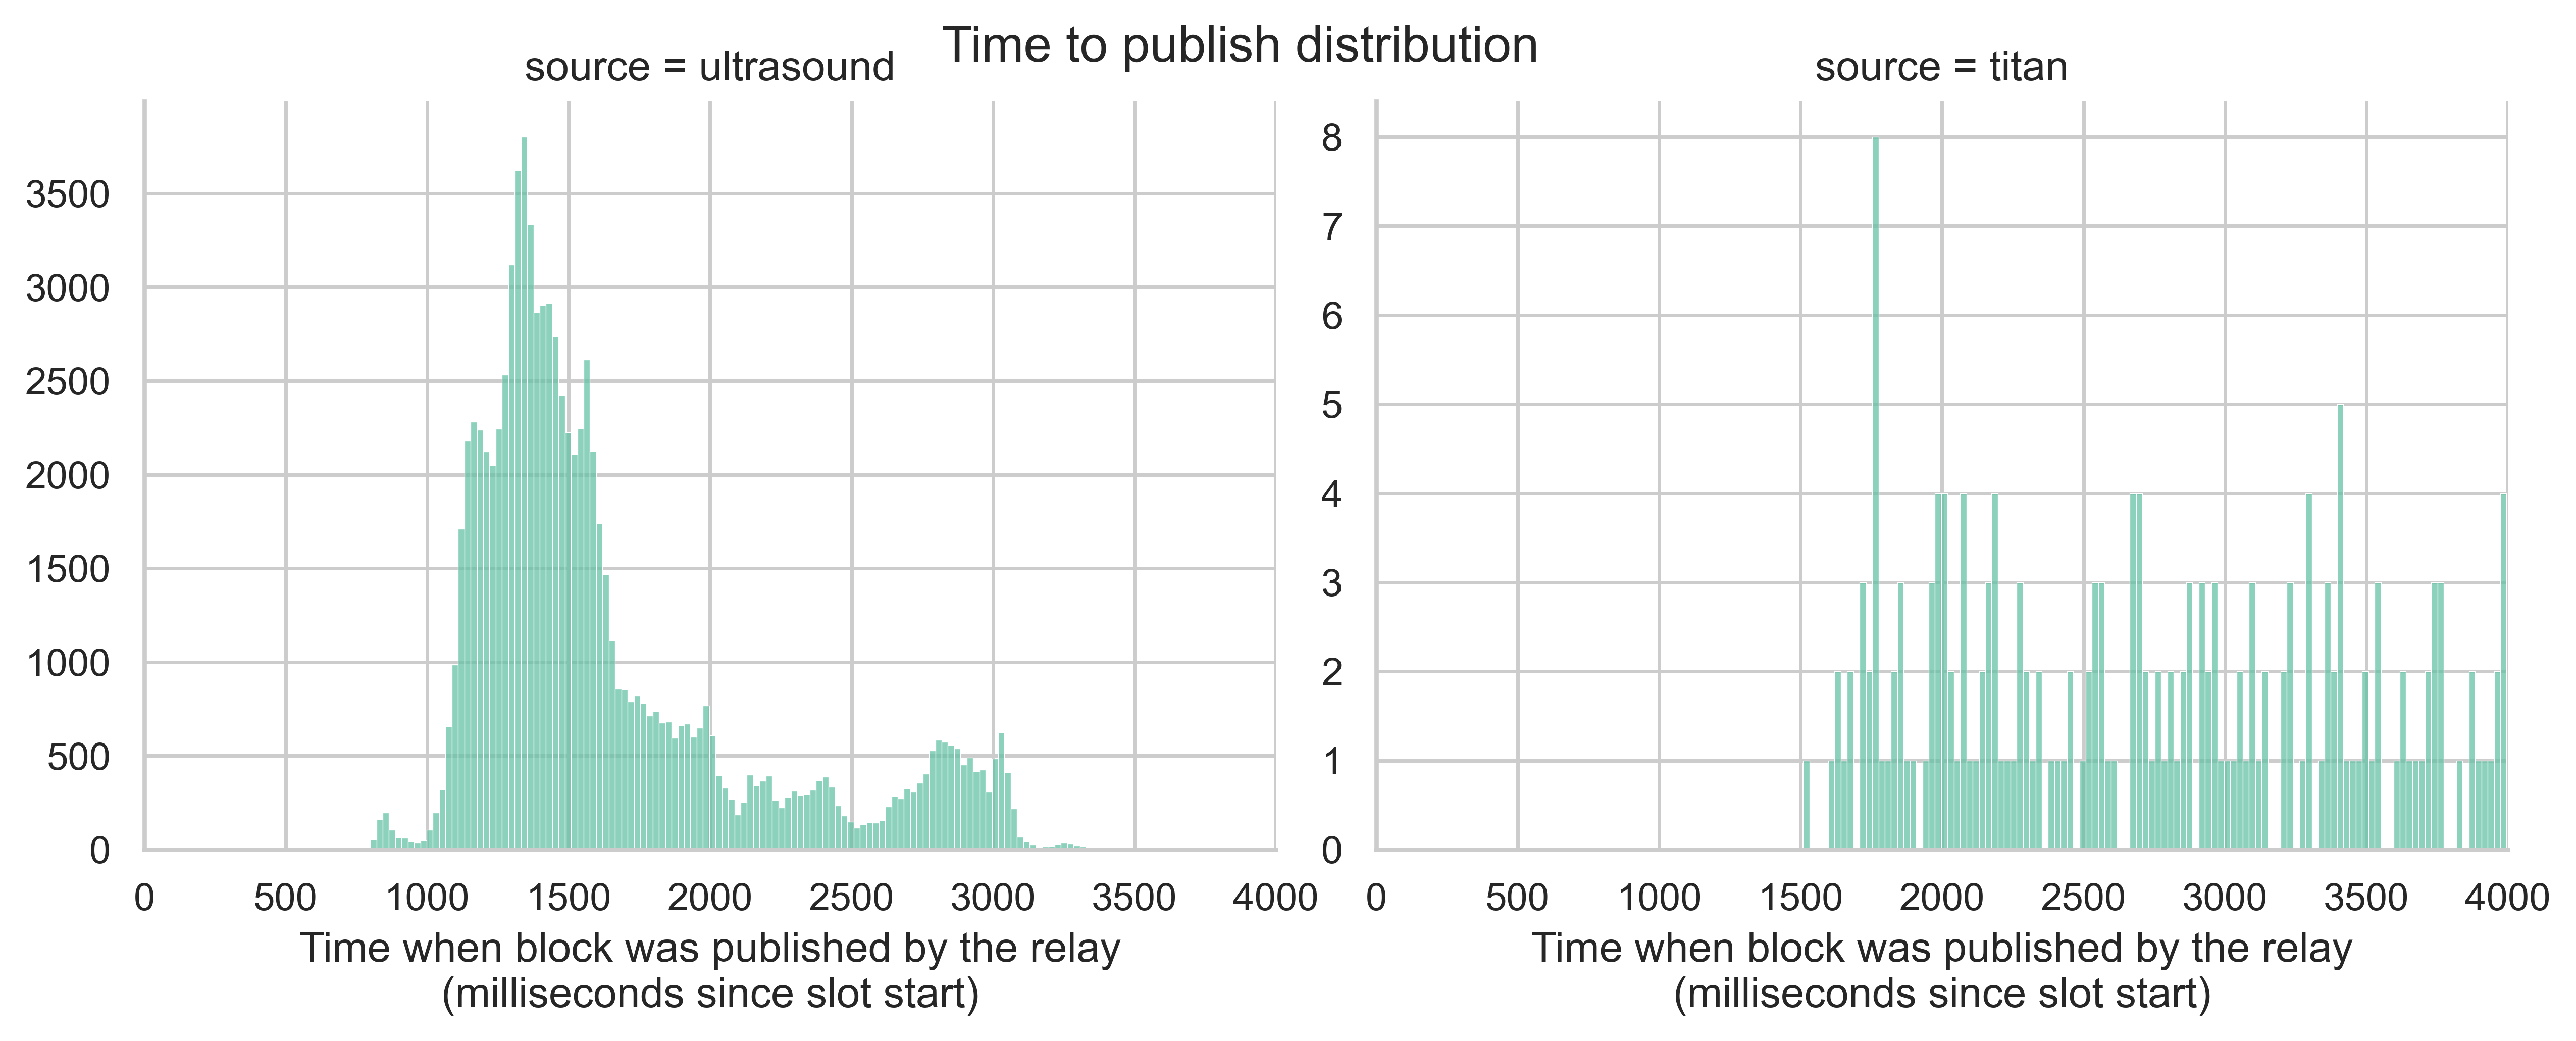

In [50]:

g = sns.displot(
    data=relay_df,
    x="slot_start_to_publish",
    col="source",
    kind="hist",
    height=4, aspect=1.3,
    facet_kws={"sharey":False}
)
g.set(xlim=(0,4000))
g.set_xlabels("Time when block was published by the relay\n(milliseconds since slot start)")
g.set_ylabels("")
plt.suptitle("Time to publish distribution")
plt.show()

In [54]:
relay_df["slot_start_to_publish"].agg(["min", "max", "mean", "std"])

min      510.000000
max     3995.012785
mean    1647.476081
std      522.748609
Name: slot_start_to_publish, dtype: float64

In [55]:
relay_df["slot_start_to_publish"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    1306.0
0.50    1466.0
0.75    1808.0
0.90    2631.0
0.95    2874.0
0.99    3051.0
Name: slot_start_to_publish, dtype: float64